# $H_2$/cc-pVDZ analysis

This notebook is the self-contained release calculation for $H_2$ in the
cc-pVDZ basis: the spin-resolved entanglement observables of the reference
manuscript: Von Neumann entropies, mutual informations, and the opposite-spin reduced two-body 
negativity, for the exact ground state and a low-temperature thermal state
along the dissociation curve.  

The heavy lifting lives in two companion modules:

| File | Role |
|---|---|
| [`h2_core.py`](h2_core.py) | electronic structure, spin-block observables, thermal mixture |
| [`h2_rdm.py`](h2_rdm.py) | compact particle-RDM contraction engine |

## 1. Model and conventions

* **Molecule:** Neutral $H_2$: H at the origin and at $(0,0,R)$.  
  Spherical cc-pVDZ gives 10 spatial orbitals, i.e. 20 interleaved
  spin orbitals ($\alpha \to 2p$, $\beta \to 2p+1$).
* **Exact solution:** The complete fixed $(N_\uparrow, N_\downarrow) = (1,1)$,
  $M_S = 0$ sector: $10^2 = 100$ determinants, diagonalized exactly.
* **RDM convention:** Particle RDMs are *unnormalized*:
  $\mathrm{Tr}\,\rho^{(1)}_\sigma = 1$, $\mathrm{Tr}\,\rho^{(2)} =
  \mathrm{Tr}\,\rho^{(2)}_{\uparrow\downarrow} = 1$ and
  $\mathrm{Tr}\,\rho^{(2)}_{\uparrow\uparrow} =
  \mathrm{Tr}\,\rho^{(2)}_{\downarrow\downarrow} = 0$.  
  All entropies are in bits (log base 2), evaluated on the unnormalized matrices.
* **Thermal state:** A Gibbs mixture at $\beta = 1000\,E_h^{-1}$ over the
  complete $M_S = 0$ spectrum.

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from pyscf import lib
lib.num_threads(1)   

import h2_core as core

GRID = core.compute_grid()               
BETA = core.DEFAULT_BETA_HARTREE_INVERSE
FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)
STAGE_SECONDS = {}

def save_figure(fig, stem):
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(FIGURE_DIR, f"{stem}.{ext}"), dpi=300, bbox_inches="tight")



## 2. Method

For every bond distance $R$:

1. **Electronic structure:** Real RHF orbitals and MO integrals,
   the complete $100\times100$ $M_S=0$ Hamiltonian assembled column by
   column from PySCF's direct Hamiltonian action and diagonalized exactly.
   `eigh` mixes spin inside energy clusters, so each
   cluster is simultaneously diagonalized in $\hat H$ and $\hat S^2$:
   projected $\hat S^2$ splits the cluster by spin, the projected
   Hamiltonian is re-diagonalized inside every equal-spin subspace, and the roots
   are re-sorted. 
2. **Reduced density matrices:** Targeted contraction plans
   (`alpha`, `beta`, `ab`, plus the structurally empty `aa`/`bb`) contract
   the compact blocks directly from the CI vector.
3. **The two-electron structure:** For $(1,1)$ the ordered-product
   $\uparrow\downarrow$ block is the complete fixed-sector density
   matrix.
4. **Observables:** $E_{\uparrow\downarrow}$ from the Schmidt decomposition of
   the CI matrix, and
   $I_{\uparrow\downarrow} = S(\rho_\uparrow)+S(\rho_\downarrow)-S(\rho)$.
   $I^{(2)}_{\uparrow\downarrow} = N_\downarrow S(\rho^{(1)}_\uparrow) +
   N_\uparrow S(\rho^{(1)}_\downarrow) - S(\rho^{(2)}_{\uparrow\downarrow})$;
   $\mathcal N^{(2)}_{\uparrow\downarrow} = \tfrac12(\lVert
   (\rho^{(2)}_{\uparrow\downarrow})^{T_\downarrow}\rVert_1 - N_\uparrow
   N_\downarrow)$, evaluated as $-\sum_i\lambda_i^{(-)}$; the reported value is
   $0.5\times$ this formula.

## 3. Dissociation-curve scan

One pass over the 57-point scan grid produces every
ground-state and thermal observable

In [2]:
t0 = time.time()
POINTS = core.run_scan(GRID, beta_hartree_inverse=BETA)
STAGE_SECONDS["scan"] = time.time() - t0

PLOT = [core.point_at(POINTS, r) for r in core.SCAN_GRID_ANGSTROM]
R = np.array([p["r"] for p in PLOT])
E_FCI = core.curve(PLOT, "gs", "e_fci")

H2/cc-pvdz scan:   0%|          | 0/57 [00:00<?, ?it/s]

## 4. Potential-energy curves 


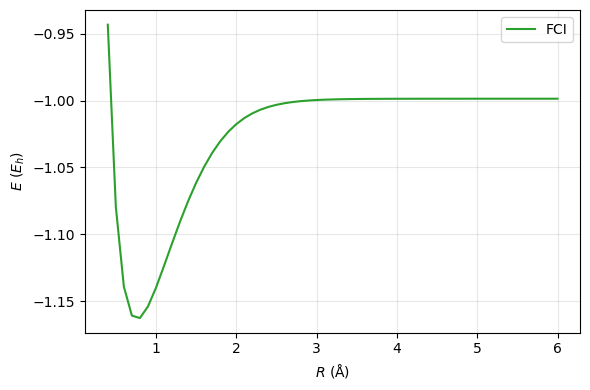

In [3]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
axes.plot(R, E_FCI, color="tab:green", label="FCI")
axes.set_xlabel(r"$R$ ($\mathrm{\AA}$)"); axes.set_ylabel(r"$E$ ($E_h$)")
axes.legend(); axes.grid(alpha=0.3)
fig.tight_layout(); save_figure(fig, "01_energies"); plt.show()


## 5. Opposite-spin two-body negativity

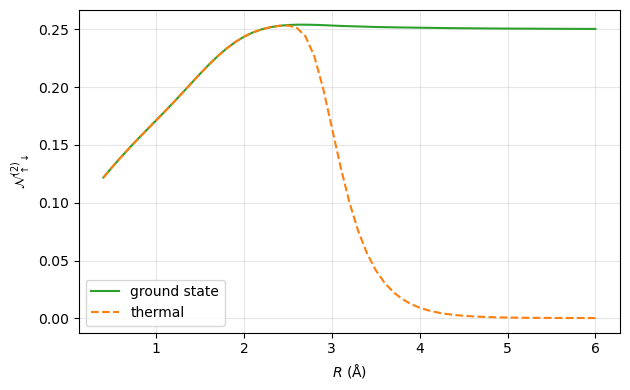

In [4]:
N2 = {state: core.curve(PLOT, state, "n2_ab") for state in ("gs", "thermal")}
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(R, N2["gs"], color="tab:green", label="ground state")
ax.plot(R, N2["thermal"], color="tab:orange", linestyle="--",
        label=r"thermal")
ax.set_xlabel(r"$R$ ($\mathrm{\AA}$)")
ax.set_ylabel(r"$\mathcal{N}^{(2)}_{\uparrow\downarrow}$")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); save_figure(fig, "02_negativity"); plt.show()

## 6. Mutual informations 

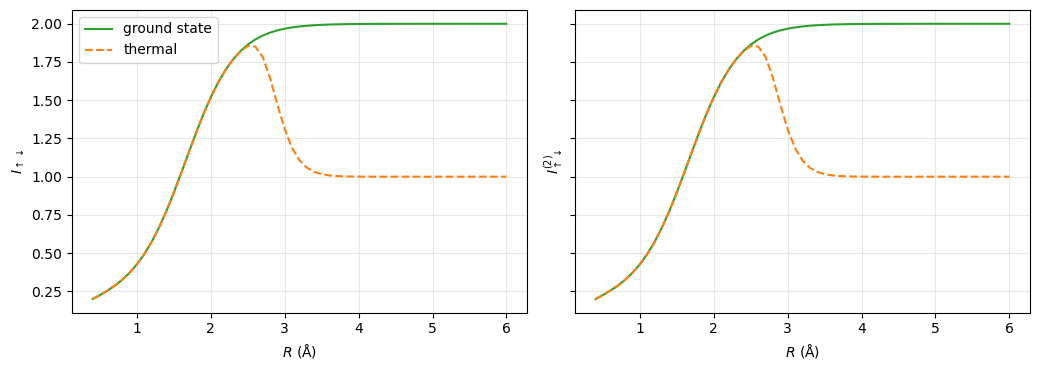

In [5]:
I_GLOBAL = {state: core.curve(PLOT, state, "i_ab") for state in ("gs", "thermal")}
I_TWOBODY = {state: core.curve(PLOT, state, "i2_ab") for state in ("gs", "thermal")}

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True)
for ax, data, label in (
    (axes[0], I_GLOBAL, r"$I_{\uparrow\downarrow}$"),
    (axes[1], I_TWOBODY, r"$I^{(2)}_{\uparrow\downarrow}$"),
):
    ax.plot(R, data["gs"], color="tab:green", label="ground state")
    ax.plot(R, data["thermal"], color="tab:orange", linestyle="--",
            label=r"thermal")
    ax.set_xlabel(r"$R$ ($\mathrm{\AA}$)")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
axes[0].legend()
fig.tight_layout(); save_figure(fig, "03_mutual_information"); plt.show()

## 7. Basis-convergence analysis: STO-3G / cc-pVDZ / cc-pVTZ

The same fixed system across three bases. The negativity
peak is related to the basis: absent in STO-3G (monotone approach to $1/4$),
$\approx 0.254$ at $2.7$ Å in cc-pVDZ, growing to $\approx 0.278$ in cc-pVTZ,
while the dissociation asymptotes are basis-stable.

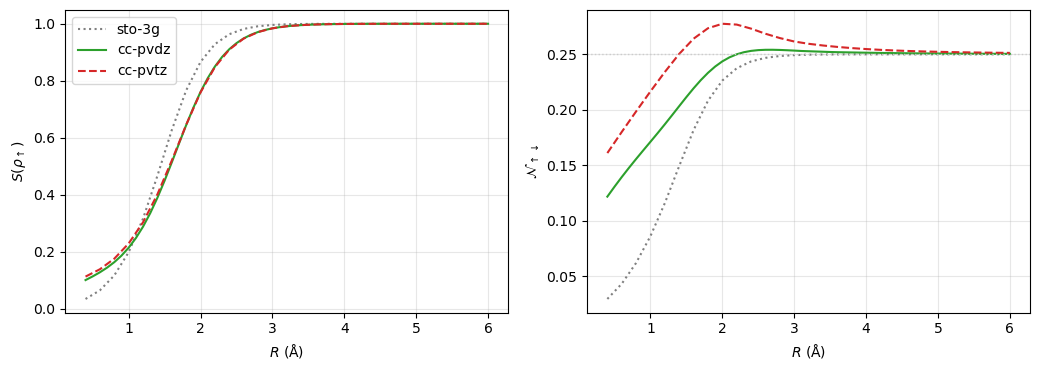

In [6]:
t0 = time.time()
PANEL_GRID = tuple(np.round(np.arange(0.4, 6.0001, 0.2), 10))
PANEL = {basis: [core.lowdin_shull_oracle(r, basis) for r in PANEL_GRID]
         for basis in ("sto-3g", "cc-pvtz")}
STAGE_SECONDS["basis_panel"] = time.time() - t0

CURVES = {
    "sto-3g": (PANEL_GRID, np.array([o["e_ud"] for o in PANEL["sto-3g"]]),
               np.array([o["n_ud"] for o in PANEL["sto-3g"]])),
    "cc-pvdz": (R, core.curve(PLOT, "gs", "e_spin"), core.curve(PLOT, "gs", "n_spin")),
    "cc-pvtz": (PANEL_GRID, np.array([o["e_ud"] for o in PANEL["cc-pvtz"]]),
                np.array([o["n_ud"] for o in PANEL["cc-pvtz"]])),
}
STYLES = {"sto-3g": ("0.5", ":"), "cc-pvdz": ("tab:green", "-"), "cc-pvtz": ("tab:red", "--")}
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for basis, (x, e_ud, n_ud) in CURVES.items():
    color, style = STYLES[basis]
    axes[0].plot(x, e_ud, color=color, linestyle=style, label=basis)
    axes[1].plot(x, n_ud, color=color, linestyle=style, label=basis)
axes[0].set_ylabel(r"$S(\rho_{\uparrow})$")
axes[1].set_ylabel(r"$\mathcal{N}_{\uparrow\downarrow}$")
axes[1].axhline(0.25, color="0.8", linestyle=":", linewidth=1)
for ax in axes:
    ax.set_xlabel(r"$R$ ($\mathrm{\AA}$)"); ax.grid(alpha=0.3)
axes[0].legend()
fig.tight_layout(); save_figure(fig, "04_basis_panel"); plt.show()
